### Setting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re

from pathlib import Path

BASE_DIR = Path().resolve().parent   
DATA_DIR = "G:/我的云端硬盘/NLP_project"
model_dir = "G:/我的云端硬盘/NLP_project/content_models"

# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = Path("/content/drive/MyDrive/NLP_project")
# model_dir = Path("/content/drive/MyDrive/NLP_project/content_models")

def show_full(df):
    """
    Fully display a DataFrame without any truncation.
    Works for any df[...] slice.
    """
    import pandas as pd
    from IPython.display import display

    with pd.option_context(
        "display.max_colwidth", None,
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None
    ):
        display(df)

In [2]:
import torch
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using {device} as device.")

Using cuda as device.


### Load data

In [4]:
df_subchunks = pd.read_parquet(f"{DATA_DIR}/df_subchunks_raw.parquet")  

In [5]:
Content_chunks = (
    df_subchunks.loc[df_subchunks["industry"] == "Media & Creative Industries",
                     ["chunk_uid", "url", "date", "title", "topic", "chunk_text"]]
    .copy()
    .rename(columns={"topic": "topic_v0"})
)
Content_chunks.head(2)

,chunk_uid,url,date,title,topic_v0,chunk_text
19,14_0_0_0_0,https://www.musicradar.com/music-tech/artists-...,2025-11-27,"""Artists and songwriters will have full contro...",7,"""Artists and songwriters will have full contro..."
20,14_0_0_0_1,https://www.musicradar.com/music-tech/artists-...,2025-11-27,"""Artists and songwriters will have full contro...",7,Best picks for you\n\n“We’re seeing the future...


In [6]:
print(len(Content_chunks))

21157


### Bertopic

In [9]:
# ! pip install bertopic

In [14]:
### customize bertopic model
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.cluster import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

RANDOM_STATE = 27

embedding_model = SentenceTransformer("thenlper/gte-small" , device="cuda")

umap_model = UMAP(
    n_neighbors=50, # smaller n_neighbors will -> local structure -> more detailed topics
    n_components=15, # smaller n_components will -> more coarse topics
    min_dist=0.1, # smaller min_dist will -> more clustered紧凑 topics
    metric="cosine",
    random_state=RANDOM_STATE
)

# 100,20
hdbscan_model = HDBSCAN(
    min_cluster_size=200, # smaller min_cluster_size will -> more detailed topics
    min_samples=50, # smaller min_samples -> easier get into topics -> more detailed topics, but also more noise
    metric="euclidean",
    cluster_selection_method="eom"
)

vectorizer_model = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=3,                 # 关键：别太高，保住 gpt/openai/llm
    max_df=0.70,              # 砍掉跨站模板词，但不至于太猛
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-]{2,}\b",
    # 你如果想加自定义 stopwords，见下方“可选增强”
)
ctfidf_model = ClassTfidfTransformer()

# All steps together
topic_model = BERTopic(
  embedding_model=embedding_model,          # Step 1 - Extract embeddings
  umap_model=umap_model,                    # Step 2 - Reduce dimensionality
  hdbscan_model=hdbscan_model,              # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
docs = Content_chunks["chunk_text"].tolist()
topics, probs = topic_model.fit_transform(docs)

In [31]:
Content_topics = topic_model.get_topic_info()
Content_chunks_topics = Content_chunks.assign( topic=topics,  probability=probs)

In [32]:
show_full(Content_topics[["Topic", 'Representation',"Count"]])

,Topic,Representation,Count
0,-1,"[jax, cox media, wftv, news jax, boston news, fair use, ani, deals opens, window boston, window wftv]",1597
1,0,"[album, music industry, drake, tracks, grammy, lyrics, suno, songwriters, recording academy, eligible]",3736
2,1,"[sag-aftra, performers, video game, guild, wga, voice actors, filmmaking, filmmakers, film festival, crabtree-ireland]",2869
3,2,"[steam, gamer, npcs, valve, game development, nintendo, depot, xbox, gameplay, video games]",1816
4,3,"[dress, kardashian, mailonline, gown, perry, gala, bikini, nyc, princess, chic]",1669
5,4,"[maine, maine public, fox news, classical, higgins, pbs, public television, president donald, kamala harris, obama]",1455
6,5,"[porn, sexual abuse, deepfakes, pornography, child sexual, deepfake porn, stanford, nude, sexually, explicit images]",825
7,6,"[mckernan, painting, ortiz, paintings, auction, christie, digital art, karla, karla ortiz, exhibition]",813
8,7,"[bahamas, bahamian, stew, derek, catalano, derek catalano, islands, nassau, pinterest, people places]",624
9,8,"[copyright office, fair use, diffusion, copyright protection, stable diffusion, authorship, outputs, copyright law, thaler, infringing]",571


In [33]:
Content_topics.to_csv(f"{DATA_DIR}/Content_specific/Content_topics.csv", index=False)
Content_chunks_topics.to_parquet(f"{DATA_DIR}/Content_specific/Content_chunks_topics.parquet", index=False)

### Filter AI Impact related content

In [44]:
manual_related_topics = [0,1,2,5,6,8,9,11,12,13,14,15,16,21,22]
df_ai_impact = Content_chunks_topics.loc[Content_chunks_topics["topic"].isin(manual_related_topics)].copy()
print(len(df_ai_impact))

14156


In [45]:
df_ai_impact.to_parquet(f"{DATA_DIR}/Content_specific/content_meaningful_df_ai_impact.parquet", index=False)

### Sentiment Analysis on chunk level

In [3]:
df_ai_impact = pd.read_parquet(f"{DATA_DIR}/Content_specific/content_meaningful_df_ai_impact.parquet")

##### 1. use LLM to generate 100 labels

In [4]:
df_ai_impact['topic'].value_counts()    

,count
topic,
0,3736
1,2869
2,1816
5,825
6,813
8,571
9,560
11,478
12,459


In [5]:
def topic_sample_n(topic_size):
    if topic_size >= 2000:
        return 100
    elif topic_size >= 800:
        return 50
    elif topic_size >= 400:
        return 20
    else:
        return 15

random_state = 38

df_ai_impact_sample = (
    df_ai_impact
    .groupby("topic", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), topic_sample_n(len(x))),
        random_state=random_state
    ))
    .reset_index(drop=True)
)

df_ai_impact_sample = df_ai_impact_sample[["chunk_uid", "topic", "chunk_text"]]
print(len(df_ai_impact_sample))
df_ai_impact_sample["topic"].value_counts()

530


C:\Users\ss363\AppData\Local\Temp\ipykernel_3688\15822918.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


topic
0     100
1     100
2      50
5      50
6      50
8      20
9      20
11     20
12     20
13     20
14     20
15     15
16     15
21     15
22     15
Name: count, dtype: int64

In [7]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [6]:
system_msg = """
You are an expert analyst of the Media & Creative Industries.

Your task is to evaluate the directional impact of AI or AI-related developments
on the media and creative industries described in the text.

These industries include but not limited to:
- music and songwriting
- film and television production
- animation and visual effects
- video games
- publishing and books
- news organizations and journalism
- digital art and creative content
- entertainment franchises and studios

You must classify the impact into EXACTLY ONE of the following:

1. "positively"

Definition:
The text suggests that AI or related technologies are expected to benefit
media or creative industries, companies, or creators.

Examples include:
- increased creative productivity
- faster content production
- cost reduction in media production
- improved visual effects or animation workflows
- enhanced game development tools
- new creative tools for artists, musicians, writers, or designers
- new entertainment formats or experiences
- expansion of creative industries through AI-assisted production

2. "negatively"

Definition:
The text suggests that AI or related technologies are expected to harm,
threaten, or create risks for creators, media organizations, or the creative ecosystem.

Examples include:
- job displacement of artists, writers, musicians, or actors
- disputes over copyright or intellectual property
- AI-generated content replacing human creators
- training data controversies involving copyrighted material
- legal battles between creators and AI companies
- reputational risks from AI-generated media
- misuse of voice, likeness, or creative style
- economic pressure on creative professions

3. "hard-to-say"

Definition:
The text is neutral, mixed, uncertain, or descriptive without a clear
positive or negative direction.

Examples include:
- both benefits and risks are discussed without a dominant direction
- the article explains AI technology without evaluating its impact
- the text describes industry reactions or debates without clear conclusions
- the impact of AI is speculative or unclear

### Decision Rules

- Focus on the MAIN directional implication of the text.
- Evaluate impact specifically in the context of media and creative industries.
- Consider effects on creators, studios, publishers, journalists, game developers,
  production companies, and entertainment companies.
- Do not over-interpret isolated optimistic or pessimistic phrases.
- If both positive and negative effects appear without a clear dominant direction,
  choose "hard-to-say".
- If the text is mostly descriptive or factual without a clear judgment,
  choose "hard-to-say".
- Ignore boilerplate text, navigation fragments, advertisements, or unrelated content.
- Base your decision only on substantive content.

### Output Requirements

Return valid JSON with exactly two fields:

{
  "impact_label": "...",
  "reasoning": "..."
}

Where:
- "impact_label" must be one of: "positively", "negatively", "hard-to-say"
- "reasoning" should briefly explain the evidence for the classification in the context of media and creative industries.
"""

impact_user_template = """
Here is a text segment from the Media & Creative Industries domain:

{chunk_text}

Please determine whether AI is expected to impact the industry,
organizations, or creators positively, negatively, or in an unclear/mixed way.

Return JSON only.
"""

impact_schema = {
    "type": "object",
    "properties": {
        "impact_label": {
            "type": "string",
            "enum": ["positively", "negatively", "hard-to-say"]
        },
        "reasoning": {
            "type": "string"
        }
    },
    "required": ["impact_label", "reasoning"],
    "additionalProperties": False
}

In [8]:
@retry(
    retry=retry_if_exception_type((
        openai.RateLimitError,
        openai.APIConnectionError,
        openai.APITimeoutError,
        openai.InternalServerError
    )),
    wait=wait_exponential(multiplier=1, min=2, max=20),
    stop=stop_after_attempt(4),
    reraise=True
)
def get_answer(client, system_msg, user_msg, model="deepseek-chat"):
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )
    content = completion.choices[0].message.content
    return json.loads(content)

VALID_LABELS = {"positively", "negatively", "hard-to-say"}

def normalize_impact_result(result):
    fallback = {
        "impact_label": "hard-to-say",
        "reasoning": "Unclear or insufficient directional evidence."
    }

    if not isinstance(result, dict):
        return fallback

    label = result.get("impact_label")
    reasoning = result.get("reasoning", "")

    if label not in VALID_LABELS:
        return fallback

    if not isinstance(reasoning, str) or not reasoning.strip():
        reasoning = fallback["reasoning"]

    normalized = {
        "impact_label": label,
        "reasoning": reasoning.strip()
    }

    try:
        validate(instance=normalized, schema=impact_schema)
        return normalized
    except ValidationError:
        return fallback

In [9]:
train_ai_impact_label = []

for idx, row in df_ai_impact_sample.iterrows():

    text = row["chunk_text"]

    user_msg = impact_user_template.format(
        chunk_text=text[:12000]
    )

    try:
        raw_result = get_answer(
            client=client,
            system_msg=system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )
        result = normalize_impact_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "impact_label": None,
            "reasoning": None,
            "api_status": f"failed: {err_msg}"
        }

        print(f"[Row {idx}] Failed: {e}")

    result["chunk_text"] = text
    result["topic"] = row["topic"]
    result['chunk_uid'] = row['chunk_uid']

    train_ai_impact_label.append(result)

In [10]:
df_train_ai_impact_label = pd.DataFrame(train_ai_impact_label)
display(df_train_ai_impact_label['impact_label'].value_counts())
imbalanced_df = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively'][['chunk_uid','chunk_text', 'reasoning']]
imbalanced_labels = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively']['chunk_uid'].to_list()
# print(imbalanced_labels)
# show_full(imbalanced_df[['chunk_uid','reasoning']])

impact_label
negatively     251
hard-to-say    154
positively     125
Name: count, dtype: int64

In [11]:
df_train_ai_impact_label.to_parquet(f"{DATA_DIR}/Content_specific/content_ai_impact_train.parquet", index=False)

##### 2. finetune classifer

In [5]:
df_train_ai_impact_label = pd.read_parquet(f"{DATA_DIR}/Content_specific/content_ai_impact_train.parquet")
display(df_train_ai_impact_label['impact_label'].value_counts())

,count
impact_label,
negatively,251
hard-to-say,154
positively,125


In [6]:
label2id = {
    "negatively": 0,
    "hard-to-say": 1,
    "positively": 2
}

id2label = {v: k for k, v in label2id.items()}

df_train = (
    df_train_ai_impact_label.loc[df_train_ai_impact_label["impact_label"].isin(label2id.keys()), ["chunk_text", "impact_label"]]
    .rename(columns={"chunk_text": "text"})
    .copy()
)

df_train["label"] = df_train["impact_label"].map(label2id)
df_train = df_train[["text", "label"]].reset_index(drop=True)

df_train.head()

,text,label
0,The deal with Nvidia follows several other AI ...,2
1,Former Daft Punk member is 'terrified' by the ...,0
2,"However, by 1984 the Tennessee Legislature pas...",0
3,Also: What is Suno? The 'ChatGPT for music' ge...,2
4,OpenAI Reportedly Developing New AI Tool That ...,2


In [23]:
from sklearn.model_selection import train_test_split
train_df, valid_df = train_test_split( df_train, test_size=0.15, random_state=42, stratify=df_train["label"])
print(train_df["label"].value_counts())
print(valid_df["label"].value_counts())

from datasets import Dataset, DatasetDict
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True), preserve_index=False)
valid_dataset = Dataset.from_pandas(valid_df.reset_index(drop=True), preserve_index=False)

dataset_dict = DatasetDict({ "train": train_dataset, "validation": valid_dataset})
dataset_dict

label
0    213
1    131
2    106
Name: count, dtype: int64
label
0    38
1    23
2    19
Name: count, dtype: int64


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 450
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 80
    })
})

In [24]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

max_len = 512
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_len,
        padding=False,
    )

tokenized_datasets = dataset_dict.map(tokenize_fn, batched=True)
tokenized_datasets

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 450
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 80
    })
})

In [25]:
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "macro_f1": f1,
        "macro_precision": precision,
        "macro_recall": recall
    }

trained_model_name = "content_ai_impact_classifier"

training_args = TrainingArguments(
    output_dir=f"{model_dir}/{trained_model_name}_ckpt",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    learning_rate=2e-5,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [26]:
trainer.train()
trainer.save_model(f"{model_dir}/{trained_model_name}")
tokenizer.save_pretrained(f"{model_dir}/{trained_model_name}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,No log,0.984091,0.475000,0.214689,0.158333,0.333333
2,0.992712,0.844193,0.637500,0.561466,0.748148,0.551869
3,0.992712,0.696072,0.662500,0.607943,0.658547,0.598398
4,0.675496,0.716753,0.700000,0.640665,0.707183,0.636537
5,0.675496,0.611551,0.750000,0.728146,0.753321,0.720824
6,0.391779,0.731161,0.712500,0.676468,0.741126,0.656369
7,0.249387,0.601815,0.762500,0.747619,0.775789,0.735317
8,0.249387,0.640685,0.737500,0.715219,0.745792,0.700229


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/NLP_project/content_models/content_ai_impact_classifier/tokenizer_config.json',
 '/content/drive/MyDrive/NLP_project/content_models/content_ai_impact_classifier/tokenizer.json')

              precision    recall  f1-score   support

  negatively       0.74      0.89      0.81        38
 hard-to-say       0.71      0.52      0.60        23
  positively       0.88      0.79      0.83        19

    accuracy                           0.76        80
   macro avg       0.78      0.74      0.75        80
weighted avg       0.76      0.76      0.75        80



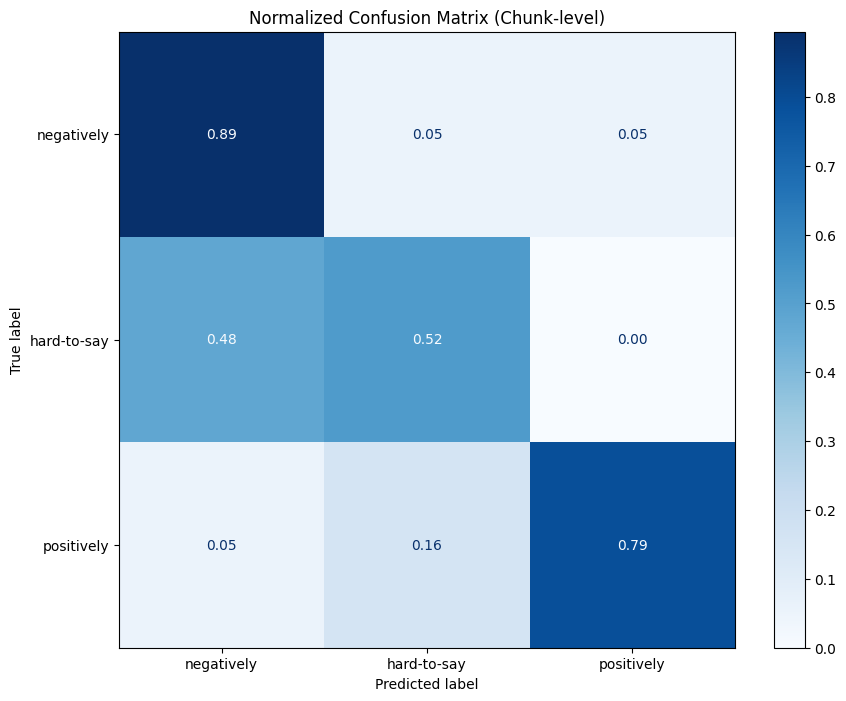

In [27]:
from sklearn.metrics import classification_report
val_pred = trainer.predict(tokenized_datasets["validation"])
val_preds = np.argmax(val_pred.predictions, axis=-1)
val_labels = np.array(tokenized_datasets["validation"]["label"])

print(classification_report(
    val_labels,
    val_preds,
    target_names=[id2label[i] for i in sorted(id2label.keys())],
    zero_division=0
))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(val_labels, val_preds, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[id2label[i] for i in sorted(id2label.keys())])
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Normalized Confusion Matrix (Chunk-level)")
plt.show()

##### 3. predict sentiment labels for all df_ai_impact chunks with the fine tuned model

In [30]:
print(df_ai_impact.shape)
df_ai_impact['topic'].value_counts()    

(14156, 8)


,count
topic,
0,3736
1,2869
2,1816
5,825
6,813
8,571
9,560
11,478
12,459


In [31]:
from datasets import Dataset

df_ai_impact_pred = (
    df_ai_impact[['chunk_uid','url','date','title',"topic", "chunk_text"]]
    .rename(columns={"chunk_text": "text"})
    .reset_index(drop=True)
    .copy()
)

pred_dataset = Dataset.from_pandas(df_ai_impact_pred, preserve_index=False)
pred_dataset = pred_dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/14156 [00:00<?, ? examples/s]

In [32]:
pred_output = trainer.predict(pred_dataset)
logits = pred_output.predictions

pred_ids = np.argmax(logits, axis=-1)
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

# df_ai_impact_pred["pred_label_id"] = pred_ids
df_ai_impact_pred["pred_label"] = [id2label[i] for i in pred_ids]
df_ai_impact_pred["max_prob"] = probs.max(axis=1)

for i, label_name in id2label.items():
    df_ai_impact_pred[f"prob_{label_name}"] = probs[:, i]

print(df_ai_impact_pred.shape)
df_ai_impact_pred.head()

(14156, 11)


,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively
0,14_0_0_0_0,https://www.musicradar.com/music-tech/artists-...,2025-11-27,"""Artists and songwriters will have full contro...",0,"""Artists and songwriters will have full contro...",negatively,0.683345,0.683345,0.080035,0.236619
1,14_0_0_0_1,https://www.musicradar.com/music-tech/artists-...,2025-11-27,"""Artists and songwriters will have full contro...",0,Best picks for you\n\n“We’re seeing the future...,hard-to-say,0.506218,0.068543,0.506218,0.425239
2,14_1_0_0_0,https://www.musicradar.com/music-tech/artists-...,2025-11-27,"""Artists and songwriters will have full contro...",0,Music Industry\nWill SimpsonNews and features ...,positively,0.519818,0.077908,0.402273,0.519818
3,29_0_0_0_0,https://www.wtvm.com/prnewswire/2023/12/07/cha...,2023-12-07,"""ChatGPT for Music"": AI Music Producer Creates...",0,"""ChatGPT for Music"": AI Music Producer Creates...",positively,0.902967,0.040893,0.056140,0.902967
4,29_0_0_0_1,https://www.wtvm.com/prnewswire/2023/12/07/cha...,2023-12-07,"""ChatGPT for Music"": AI Music Producer Creates...",0,"""The artists asked the AI to create beats infl...",positively,0.848791,0.056533,0.094675,0.848791


/tmp/ipykernel_5775/602985794.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


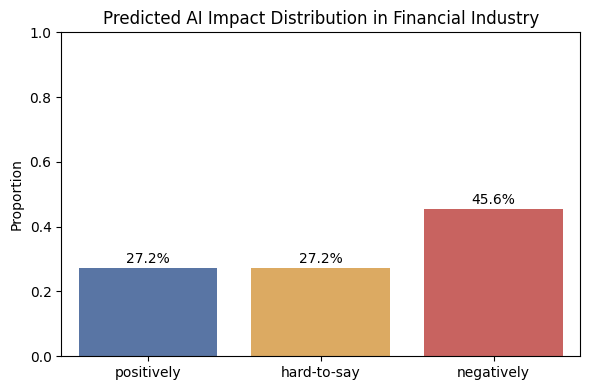

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ["positively", "hard-to-say", "negatively"]
dist = df_ai_impact_pred["pred_label"].value_counts(normalize=True).reindex(order)

plt.figure(figsize=(6, 4))

sns.barplot(
    x=dist.index,
    y=dist.values,
    palette=["#4C72B0", "#F0AD4E", "#D9534F"]
)

plt.ylabel("Proportion")
plt.xlabel("")
plt.title("Predicted AI Impact Distribution in Media & Creative Industry")
plt.ylim(0, 1)

for i, v in enumerate(dist.values):
    plt.text(i, v + 0.015, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [34]:
df_ai_impact_pred.to_parquet(f"{DATA_DIR}/Content_specific/{trained_model_name}_predictions.parquet", index=False)

### NER: Company and Technologies

In [2]:
df_ai_impact_pred = pd.read_parquet(f"{DATA_DIR}/Content_specific/content_ai_impact_classifier_predictions.parquet")
print(len(df_ai_impact_pred))
df_ai_impact_pred.head(2)

14156


,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively
0,14_0_0_0_0,https://www.musicradar.com/music-tech/artists-...,2025-11-27,"""Artists and songwriters will have full contro...",0,"""Artists and songwriters will have full contro...",negatively,0.683345,0.683345,0.080035,0.236619
1,14_0_0_0_1,https://www.musicradar.com/music-tech/artists-...,2025-11-27,"""Artists and songwriters will have full contro...",0,Best picks for you\n\n“We’re seeing the future...,hard-to-say,0.506218,0.068543,0.506218,0.425239


#### Positive impact

In [5]:
df_ai_impact_ner_sample_pos = df_ai_impact_pred.loc[df_ai_impact_pred['pred_label'] == 'positively'].sample(800, random_state=38).reset_index(drop=True)

In [ ]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [7]:
pos_entity_system_msg = """\
You are an information extraction system for media and creative industry news articles.

The user will provide a text block from a media or creative industry article.
Your task is to extract only the following:

1. organizations or companies in the media and creative ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or positive impact mechanisms explicitly mentioned in the text

## ORGANIZATIONS
Extract named organizations, companies, studios, publishers, platforms, unions, or institutions explicitly stated in the text.

This may include:
- film and television studios
- music labels or production companies
- video game companies
- publishing houses
- animation studios
- streaming platforms
- news organizations
- media technology companies
- creative industry unions or associations
- entertainment companies or franchises

Examples:
- Disney
- Pixar
- Warner Bros
- Netflix
- Sony Music
- Universal Music Group
- Valve
- Steam
- The New York Times
- SAG-AFTRA
- OpenAI
- Amazon Kindle
- Adobe

## AI_TECHNOLOGIES_OR_MECHANISMS
Extract AI-related technologies, creative tools, or positive impact mechanisms explicitly mentioned in the text.

This includes, but is not limited to:
- generative AI
- large language models
- machine learning
- text-to-image generation
- text-to-video generation
- AI-assisted animation
- AI-assisted video editing
- music generation models
- voice synthesis
- creative co-pilot tools
- automated content production
- visual effects automation
- game development AI tools
- productivity improvement
- cost reduction in media production
- faster content creation
- creative workflow automation
- personalized media experiences
- recommendation systems

## Directions
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the studio”, “the company”, “the platform”, or “creators” unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""

entity_user_template = """\
Title: {title}

Text:
{text}
"""

entity_json_schema = {
    "type": "object",
    "properties": {
        "organizations": {
            "type": "array",
            "items": {"type": "string"}
        },
        "ai_technologies_or_mechanisms": {
            "type": "array",
            "items": {"type": "string"}
        }
    },
    "required": ["organizations", "ai_technologies_or_mechanisms"],
    "additionalProperties": False
}

In [8]:
def normalize_entity_result(result):
    fallback = {
        "organizations": [],
        "ai_technologies_or_mechanisms": []
    }

    if not isinstance(result, dict):
        return fallback

    orgs = result.get("organizations", [])
    ai_items = result.get("ai_technologies_or_mechanisms", [])

    if not isinstance(orgs, list):
        orgs = []
    if not isinstance(ai_items, list):
        ai_items = []

    # 只保留非空字符串，并去重
    def clean_list(x):
        cleaned = []
        seen = set()
        for item in x:
            if isinstance(item, str):
                s = item.strip()
                if s and s not in seen:
                    cleaned.append(s)
                    seen.add(s)
        return cleaned

    normalized = {
        "organizations": clean_list(orgs),
        "ai_technologies_or_mechanisms": clean_list(ai_items)
    }

    try:
        validate(instance=normalized, schema=entity_json_schema)
        return normalized
    except ValidationError:
        return fallback
    
def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )

    content = response.choices[0].message.content
    return json.loads(content)

In [9]:
train_ai_positive_impact_ner = []

for idx, row in df_ai_impact_ner_sample_pos.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=pos_entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    train_ai_positive_impact_ner.append(result)
    
df_ai_positive_impact_ner_result = pd.DataFrame(train_ai_positive_impact_ner)

In [10]:
df_ai_positive_impact_ner_result

,organizations,ai_technologies_or_mechanisms,api_status,chunk_uid,title,text,pred_label,topic
0,"[Activision, Modulate]","[artificial intelligence, real-time voice chat...",success,27370_0_0_0_0,Call of Duty: Modern Warfare 3 will have AI ch...,Call of Duty: Modern Warfare 3 will have AI ch...,positively,2
1,"[News UK, News Corp, OpenAI, The Times, The Su...","[AI training, AI models, AI-powered journalism...",success,93406_0_0_0_0,News UK Partners with OpenAI for AI Training o...,News UK Partners with OpenAI for AI Training o...,positively,9
2,"[Meta AI, Facebook, MSPowerUser, Samsung, Micr...","[real-time text-to-speech conversion, text-to-...",success,140958_0_0_0_2,What is Meta's new AI module for audio composi...,Accessibility tools: MAGNeT’s real-time text-t...,positively,0
3,[],[],success,126807_0_0_0_3,The Role of Artificial Intelligence in Game Te...,AI algorithms are trained on data that is coll...,positively,2
4,"[The Beatles, BBC Radio, CBS Philadelphia]","[artificial intelligence, AI, AI-produced trac...",success,104557_0_0_0_0,Paul McCartney says AI was used to create new ...,Paul McCartney says AI was used to create new ...,positively,16
...,...,...,...,...,...,...,...,...
795,[Big FM],"[AI-powered song creation platform, custom son...",success,23211_0_0_0_0,Big FM launches AI driven custom song generati...,Big FM launches AI driven custom song generati...,positively,0
796,"[YouTube Music, Google, YouTube, YouTube Labs,...","[AI music hosts, AI-powered music DJ/host, AI ...",success,66798_0_0_0_0,How to test YouTube Music's AI music hosts: A ...,How to test YouTube Music's AI music hosts: A ...,positively,0
797,[],[],success,3411_1_0_1_0,5 ways AI will change how we live in the futur...,So fast forward and let’s go 30 times more per...,positively,1
798,"[Netflix, Academy of Motion Picture Arts and S...","[generative AI, AI-powered tools, de-aging VFX...",success,41516_0_0_0_2,Does Netflix Have the Right Artificial Intelli...,Generative AI is a cost-effective method for a...,positively,1


In [11]:
df_ai_positive_impact_ner_result.to_parquet(f"{DATA_DIR}/Content_specific/content_ai_positiveimpact_ner.parquet", index=False)

##### Organization 

In [ ]:
# df_ai_impact_ner_result_pos = pd.read_parquet(f"{DATA_DIR}/Content_specific/content_ai_positiveimpact_ner.parquet")

In [12]:
df_posorg_long = (
    df_ai_positive_impact_ner_result[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_posorg_long = df_posorg_long[df_posorg_long["organizations"].notna()].copy()
df_posorg_long["entity_raw"] = df_posorg_long["organizations"].astype(str).str.strip()
df_posorg_long = df_posorg_long[df_posorg_long["entity_raw"] != ""]

posorg_raw_counts = (
    df_posorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(posorg_raw_counts.shape)
posorg_candidates = posorg_raw_counts.loc[posorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(posorg_candidates.shape)
posorg_candidates

(1801, 2)
(392, 2)


,entity_raw,raw_count
0,OpenAI,87
1,Spotify,84
2,Google,79
3,The Beatles,45
4,YouTube,43
...,...,...
387,ABS-CBN News,2
388,Konan Technology,2
389,YouTube Labs,2
390,Condé Nast,2


In [13]:
posorg_candidate_pairs = list(posorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
posorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in posorg_candidate_pairs])
posorg_candidate_pairs_str

"- (OpenAI, 87)\n- (Spotify, 84)\n- (Google, 79)\n- (The Beatles, 45)\n- (YouTube, 43)\n- (Disney, 41)\n- (Microsoft, 36)\n- (Steam, 29)\n- (Netflix, 25)\n- (Valve, 23)\n- (TikTok, 22)\n- (Amazon, 22)\n- (BBC, 21)\n- (Suno, 21)\n- (SteamDB, 21)\n- (Universal Music Group, 18)\n- (Meta, 17)\n- (Udio, 16)\n- (Disney+, 16)\n- (OnePlus, 14)\n- (Apple, 13)\n- (Nvidia, 13)\n- (Stability AI, 13)\n- (Associated Press, 12)\n- (Midjourney, 12)\n- (The New York Times, 12)\n- (Marvel, 12)\n- (SAG-AFTRA, 12)\n- (SK Telecom, 11)\n- (AFP, 11)\n- (Runway, 11)\n- (ChatGPT, 11)\n- (Ubisoft, 11)\n- (Apple Music, 10)\n- (Pixar, 10)\n- (NPR, 10)\n- (Sony, 10)\n- (Star Wars, 10)\n- (Warner Music Group, 10)\n- (YouTube Music, 10)\n- (National Portrait Gallery, 9)\n- (Roblox, 9)\n- (Peter Jackson, 9)\n- (EA, 9)\n- (MusicRadar, 9)\n- (Axel Springer, 9)\n- (Getty Images, 8)\n- (Hollywood, 8)\n- (Deezer, 8)\n- (Samsung, 8)\n- (Adobe, 8)\n- (Xbox, 8)\n- (Activision, 8)\n- (Kakao, 7)\n- (Instagram, 7)\n- (Financial

In [14]:
org_top_system_msg = """\
You are a company name consolidation and ranking system.

The user will provide a list of organization names with mention counts extracted from Media & Creative Industries-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same company into one canonical company name.
2. Classify canonical companies into:
   - media_creative_company
   - ai_company
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return only:
   - Top 10 Media & Creative Industries companies
   - Top 10 AI companies

Rules:
- Be conservative when merging.
- Do not merge different companies.
- media_creative_company should be companies or organizations primarily in the Media & Creative Industries,
  such as film and television studios, music labels, publishers, video game companies,
  animation studios, streaming platforms, news organizations, or entertainment companies.
- ai_company should be companies primarily in AI or companies with a strong AI-product focus.
- Use counts exactly as given.
- Unclear entities should be ignored (not included in top lists).

Return valid JSON only.
"""

org_top_user_template = """\
Here is the list of (organization_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "media_creative_industry_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

org_top_json_schema = {
    "type": "object",
    "properties": {
        "media_creative_industry_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["media_creative_industry_top10", "ai_top10"],
    "additionalProperties": False
}

In [15]:
import json
import pandas as pd
from jsonschema import validate

def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )
    return json.loads(response.choices[0].message.content)

user_msg = org_top_user_template.format(candidate_list=posorg_candidate_pairs_str)

result_posorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posorg, schema=org_top_json_schema)

In [16]:
industry_company_top10_pos = pd.DataFrame(result_posorg["media_creative_industry_top10"])
ai_company_top10_pos = pd.DataFrame(result_posorg["ai_top10"])

print("Media & Creative Industry Top 10")
display(industry_company_top10_pos)

print("AI Top 10")
display(ai_company_top10_pos)

Media & Creative Industry Top 10


,canonical_name,total_count,source_raw_names
0,Spotify,84,[Spotify]
1,YouTube,43,"[YouTube, YouTube Music, YouTube Labs]"
2,Disney,41,"[Disney, Disney+, Disneyland Paris, Walt Disney]"
3,Netflix,25,[Netflix]
4,TikTok,22,[TikTok]
5,BBC,21,"[BBC, BBC Radio 4, BBC Radio]"
6,Universal Music Group,18,"[Universal Music Group, Universal Music, UMG]"
7,The New York Times,17,"[The New York Times, New York Times]"
8,Marvel,12,[Marvel]
9,Warner Music Group,10,"[Warner Music Group, Warner Music Nashville]"


AI Top 10


,canonical_name,total_count,source_raw_names
0,OpenAI,87,"[OpenAI, ChatGPT, Sora]"
1,Google,79,"[Google, Google DeepMind, DeepMind]"
2,Microsoft,36,[Microsoft]
3,Suno,25,"[Suno, Suno AI]"
4,Meta,20,"[Meta, Meta AI]"
5,Udio,16,"[Udio, Udio AI]"
6,Stability AI,13,"[Stability AI, Stable Diffusion]"
7,Midjourney,16,"[Midjourney, MidJourney]"
8,Runway,11,[Runway]
9,Anthropic,5,[Anthropic]


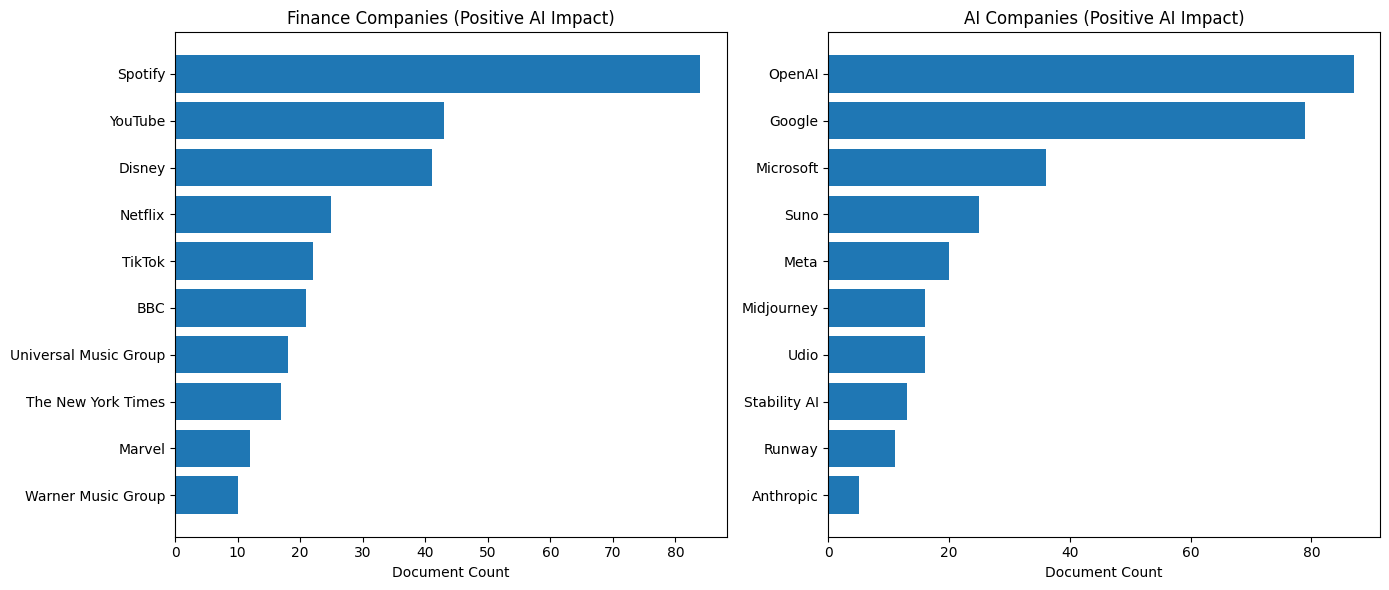

In [17]:
import matplotlib.pyplot as plt
import numpy as np

media_df = industry_company_top10_pos.sort_values("total_count")
ai_df = ai_company_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Media & Creative ---
axes[0].barh(media_df["canonical_name"], media_df["total_count"])
axes[0].set_title("Media & Creative Companies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [18]:
df_posmech_long = (
    df_ai_positive_impact_ner_result[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_posmech_long = df_posmech_long[df_posmech_long["ai_technologies_or_mechanisms"].notna()].copy()
df_posmech_long["entity_raw"] = (
    df_posmech_long["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_posmech_long = df_posmech_long[ df_posmech_long["entity_raw"] != ""]

posmech_raw_counts = (
    df_posmech_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(posmech_raw_counts.shape)

posmech_candidates = posmech_raw_counts.loc[
    posmech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(posmech_candidates.shape)

posmech_candidates

(2561, 2)
(346, 2)


,entity_raw,raw_count
0,AI,128
1,generative AI,119
2,artificial intelligence,99
3,machine learning,53
4,ChatGPT,49
...,...,...
341,AI music service,2
342,AI 'hosts',2
343,3D,2
344,voice separation,2


In [19]:
posmech_candidate_pairs = list(
    posmech_candidates[["entity_raw", "raw_count"]]
    .itertuples(index=False, name=None)
)
posmech_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in posmech_candidate_pairs])
posmech_candidate_pairs_str

"- (AI, 128)\n- (generative AI, 119)\n- (artificial intelligence, 99)\n- (machine learning, 53)\n- (ChatGPT, 49)\n- (AI tools, 41)\n- (faster content creation, 27)\n- (AI technology, 27)\n- (AI models, 27)\n- (text prompts, 21)\n- (creative workflow automation, 18)\n- (AI DJ, 17)\n- (AI-generated music, 16)\n- (Artificial intelligence, 15)\n- (AI-generated content, 15)\n- (productivity improvement, 14)\n- (cost reduction in media production, 14)\n- (AI tool, 13)\n- (AI music generator, 12)\n- (text-to-image generation, 11)\n- (AI model, 11)\n- (MusicLM, 11)\n- (music generation, 10)\n- (large language models, 10)\n- (Sora, 9)\n- (Generative AI, 9)\n- (AI training, 9)\n- (AI algorithms, 8)\n- (deep learning, 8)\n- (AI music, 8)\n- (AI Music Studio, 8)\n- (AI technologies, 8)\n- (separate voices from background sounds, 8)\n- (mix the record, 7)\n- (personalized media experiences, 7)\n- (user-generated content, 7)\n- (creative tools, 7)\n- (AI platform, 7)\n- (AI-powered tools, 7)\n- (AI 

In [23]:
posmech_top_system_msg = """\
You are an AI technology and Media & Creative Industries impact mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts extracted from Media & Creative Industries-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_media_creative_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI media & creative industry mechanisms

Definitions:

### core_ai_technology
Fundamental AI technologies, models, or technical approaches. Don't take AI and artificial intelligence as

Examples include:
- large language models
- generative AI
- machine learning
- deep learning
- neural networks
- diffusion models
- computer vision
- natural language processing
- speech synthesis
- recommendation algorithms


### ai_media_creative_mechanism
Applications, production workflows, or industry mechanisms through which AI affects the Media & Creative Industries.

Examples include:
- AI-assisted content creation
- automated video editing
- AI animation generation
- music generation
- voice cloning or voice synthesis
- script generation
- automated dubbing
- visual effects automation
- game development automation
- recommendation systems for media
- personalized content generation
- digital asset creation
- creative workflow automation
- faster content production
- cost reduction in media production


### other
Anything vague, unclear, or not clearly an AI technology or media/creative industry mechanism.


Rules:
- Merge only when raw names clearly refer to the same concept.
- Be conservative when merging.
- Keep canonical names concise and representative.
- Do not invent new concepts that are not supported by the provided raw names.
- Use counts exactly as provided.
- Only classify items as ai_media_creative_mechanism when the media/creative industry context is clear.
- machine learning, deep learning and neural networks should be grouped under machine learning.
- ChatGPT should be grouped under large language models class.

Return valid JSON only.
"""

mech_top_user_template = """\
Here is the list of (technology_or_mechanism_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "core_ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_mechanism_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

mech_top_json_schema = {
    "type": "object",
    "properties": {
        "core_ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_mechanism_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["core_ai_top10", "ai_mechanism_top10"],
    "additionalProperties": False
}

In [24]:
user_msg = mech_top_user_template.format(candidate_list=posmech_candidate_pairs_str)
result_posmech = generate_text(
    client=client,
    system_msg=posmech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posmech, schema=mech_top_json_schema)

In [25]:
technology_top10_pos = pd.DataFrame(result_posmech["core_ai_top10"])
mechanism_top10_pos = pd.DataFrame(result_posmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_pos)

print("AI Business Mechanism Top 10")
display(mechanism_top10_pos)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,generative AI,135,"[generative AI, Generative AI, generative arti..."
1,machine learning,69,"[machine learning, deep learning, neural netwo..."
2,large language models,66,"[ChatGPT, large language models, large languag..."
3,diffusion models,10,"[diffusion model, Stable Diffusion, Midjourney..."
4,natural language processing,7,"[natural language processing, natural language..."
5,computer vision,6,"[deepfake, Deepfake technology, deepfakes]"
6,speech synthesis,6,"[voice synthesis, text-to-speech]"
7,reinforcement learning,4,[reinforcement learning]
8,evolutionary algorithms,3,[evolutionary algorithms]
9,hierarchical sequence-to-sequence modeling,2,[hierarchical sequence-to-sequence modeling]


AI Business Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,music generation,88,"[AI-generated music, music generation, AI musi..."
1,voice cloning,20,"[voice cloning, voice clones, extract John Len..."
2,creative workflow automation,18,[creative workflow automation]
3,faster content creation,27,[faster content creation]
4,cost reduction in media production,17,"[cost reduction in media production, cost redu..."
5,text-to-image generation,16,"[text-to-image generation, AI image generator,..."
6,personalized media experiences,16,"[personalized media experiences, personalized ..."
7,automated content production,15,"[automated content production, AI-generated vi..."
8,recommendation systems,13,"[recommendations, recommendation systems, cont..."
9,source separation,12,"[separate voices from background sounds, separ..."


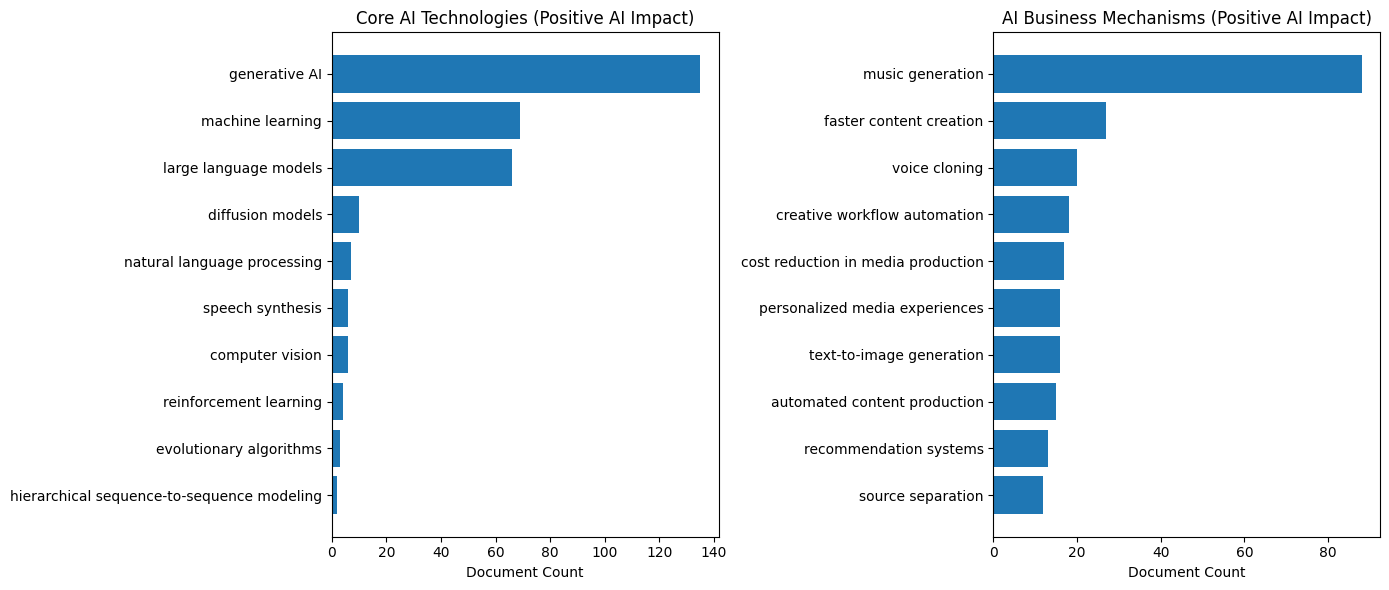

In [26]:
import matplotlib.pyplot as plt

tech_df = technology_top10_pos.sort_values("total_count")
mech_df = mechanism_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

#### Negative impact

In [27]:
df_ai_negative_impact_ner_sample = df_ai_impact_pred.loc[df_ai_impact_pred['pred_label'] == 'negatively'].sample(500, random_state=42).reset_index(drop=True)
print(len(df_ai_negative_impact_ner_sample))

500


In [28]:
neg_entity_system_msg = """\
You are an information extraction system for media and creative industry news articles.

The user will provide a text block from a media or creative industry article.
This dataset is focused on negative AI impact.

Your task is to extract only the following:

1. organizations or institutions in the media and creative ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or NEGATIVE impact mechanisms explicitly mentioned in the text


## ORGANIZATIONS
Extract named media and creative industry organizations, companies, or institutions explicitly stated in the text.

This may include:
- film and television studios
- streaming platforms
- music labels or music production companies
- video game companies
- animation studios
- publishing houses
- news organizations or media outlets
- creative industry unions or guilds
- entertainment technology companies
- regulators or cultural institutions

Examples:
- Disney
- Warner Bros
- Netflix
- Universal Music Group
- Sony Music
- Spotify
- Valve
- Steam
- The New York Times
- SAG-AFTRA
- Writers Guild of America
- Adobe


## AI_TECHNOLOGIES_OR_MECHANISMS
Extract:

- AI-related technologies or capabilities explicitly mentioned in the text
- AI-related NEGATIVE media/creative industry impact mechanisms explicitly mentioned in the text


Examples of technologies / capabilities:
- generative AI
- large language models
- machine learning
- diffusion models
- text-to-image generation
- text-to-video generation
- voice synthesis
- voice cloning
- computer vision
- natural language processing


Examples of NEGATIVE media/creative industry impact mechanisms:
- job displacement of artists or creators
- loss of creative control
- copyright infringement
- unauthorized training data use
- intellectual property disputes
- deepfake misuse
- voice cloning abuse
- artist compensation disputes
- creative labor displacement
- reputational damage
- misinformation or synthetic media risks
- decline in demand for human creators
- legal disputes over AI-generated content
- erosion of trust in media authenticity
- regulatory scrutiny
- platform liability


## Directions
- Focus especially on negative AI-related mechanisms, risks, harms, and downsides in the media and creative industries.
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the studio”, “the company”, “creators”, or “the platform” unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""

In [29]:
train_ai_negative_impact_ner = []

for idx, row in df_ai_negative_impact_ner_sample.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=neg_entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    train_ai_negative_impact_ner.append(result)
    
df_ai_negative_impact_ner_result = pd.DataFrame(train_ai_negative_impact_ner)

[Row 299] Failed: Unterminated string starting at: line 3 column 14825 (char 14915)


In [30]:
df_ai_negative_impact_ner_result.to_parquet(f"{DATA_DIR}/Content_specific/content_ai_negative_impact_ner.parquet", index=False)

##### Organization 

In [31]:
df_negorg_long = (
    df_ai_negative_impact_ner_result[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_negorg_long = df_negorg_long[df_negorg_long["organizations"].notna()].copy()
df_negorg_long["entity_raw"] = df_negorg_long["organizations"].astype(str).str.strip()
df_negorg_long = df_negorg_long[df_negorg_long["entity_raw"] != ""]

negorg_raw_counts = (
    df_negorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(negorg_raw_counts.shape)
negorg_candidates = negorg_raw_counts.loc[negorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(negorg_candidates.shape)
negorg_candidates

(720, 2)
(182, 2)


,entity_raw,raw_count
0,OpenAI,113
1,SAG-AFTRA,45
2,Microsoft,41
3,The New York Times,36
4,NPR,30
...,...,...
177,Politico,2
178,RCA Records,2
179,Xbox,2
180,Xicoia,2


In [32]:
negorg_candidate_pairs = list(negorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
negorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in negorg_candidate_pairs])
negorg_candidate_pairs_str

"- (OpenAI, 113)\n- (SAG-AFTRA, 45)\n- (Microsoft, 41)\n- (The New York Times, 36)\n- (NPR, 30)\n- (Spotify, 29)\n- (Google, 28)\n- (Meta, 27)\n- (Writers Guild of America, 22)\n- (Stability AI, 20)\n- (The Associated Press, 19)\n- (Amazon, 19)\n- (Midjourney, 18)\n- (Anthropic, 17)\n- (Netflix, 17)\n- (Authors Guild, 17)\n- (Disney, 16)\n- (YouTube, 16)\n- (Associated Press, 16)\n- (Universal Music Group, 16)\n- (New York Times, 11)\n- (WGA, 10)\n- (AMPTP, 10)\n- (TikTok, 10)\n- (Getty Images, 10)\n- (Apple, 9)\n- (X, 9)\n- (CNN, 9)\n- (Alliance of Motion Picture and Television Producers, 8)\n- (Udio, 8)\n- (Recording Academy, 8)\n- (Activision, 8)\n- (ABC News, 7)\n- (Suno, 7)\n- (U.S. Copyright Office, 7)\n- (AP, 7)\n- (BBC, 7)\n- (Variety, 7)\n- (Epic Games, 6)\n- (Reddit, 6)\n- (The Independent, 6)\n- (The Hollywood Reporter, 6)\n- (Warner Bros., 6)\n- (Facebook, 5)\n- (Hollywood, 5)\n- (Grammy Awards, 5)\n- (Recording Industry Association of America, 5)\n- (Screen Actors Guild-Am

In [33]:
user_msg = org_top_user_template.format(candidate_list=negorg_candidate_pairs_str)

result_negorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_negorg, schema=org_top_json_schema)

In [35]:
industry_company_top10_neg = pd.DataFrame(result_negorg["media_creative_industry_top10"])
ai_company_top10_neg = pd.DataFrame(result_negorg["ai_top10"])

print("Media & Creative Industry Top 10")
display(industry_company_top10_neg)

print("AI Top 10")
display(ai_company_top10_neg)

Health Industry Top 10


,canonical_name,total_count,source_raw_names
0,The New York Times,47,"[The New York Times, New York Times]"
1,SAG-AFTRA,50,"[SAG-AFTRA, Screen Actors Guild-American Feder..."
2,Associated Press,42,"[The Associated Press, Associated Press, AP]"
3,Writers Guild of America,32,"[Writers Guild of America, WGA]"
4,Netflix,17,[Netflix]
5,Disney,18,"[Disney, Walt Disney Co.]"
6,Universal Music Group,21,"[Universal Music Group, Universal Music]"
7,Spotify,29,[Spotify]
8,YouTube,16,[YouTube]
9,AMPTP,18,"[AMPTP, Alliance of Motion Picture and Televis..."


AI Top 10


,canonical_name,total_count,source_raw_names
0,OpenAI,113,[OpenAI]
1,Microsoft,43,"[Microsoft, Microsoft Corp.]"
2,Google,28,[Google]
3,Meta,31,"[Meta, Meta Platforms]"
4,Stability AI,20,[Stability AI]
5,Midjourney,18,[Midjourney]
6,Anthropic,17,[Anthropic]
7,Udio,8,[Udio]
8,Suno,10,"[Suno, Suno AI]"
9,Hugging Face,3,[Hugging Face]


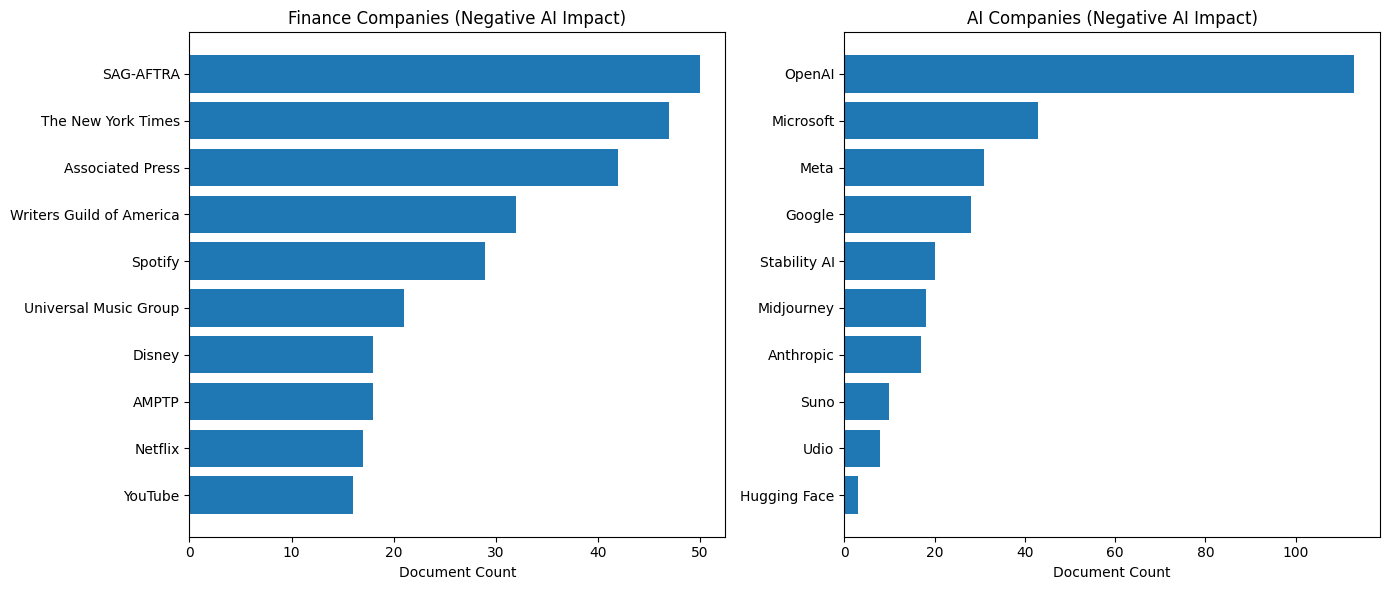

In [36]:
import matplotlib.pyplot as plt
import numpy as np

media_df = industry_company_top10_neg.sort_values("total_count")
ai_df = ai_company_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Media & Creative ---
axes[0].barh(media_df["canonical_name"], media_df["total_count"])
axes[0].set_title("Media & Creative Companies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [37]:
df_ai_mech_long_neg = (
    df_ai_negative_impact_ner_result[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_ai_mech_long_neg = df_ai_mech_long_neg[df_ai_mech_long_neg["ai_technologies_or_mechanisms"].notna()].copy()
df_ai_mech_long_neg["entity_raw"] = (
    df_ai_mech_long_neg["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_ai_mech_long_neg = df_ai_mech_long_neg[ df_ai_mech_long_neg["entity_raw"] != ""]

neg_ai_mech_raw_counts = (
    df_ai_mech_long_neg.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(neg_ai_mech_raw_counts.shape)

neg_ai_mech_candidates = neg_ai_mech_raw_counts.loc[
    neg_ai_mech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(neg_ai_mech_candidates.shape)

neg_ai_mech_candidates

(760, 2)
(129, 2)


,entity_raw,raw_count
0,unauthorized training data use,263
1,copyright infringement,178
2,artist compensation disputes,153
3,legal disputes over AI-generated content,148
4,intellectual property disputes,129
...,...,...
124,AI-generated,2
125,voice assistant,2
126,AI voice,2
127,AI version,2


In [38]:
neg_candidate_pairs = list( neg_ai_mech_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
neg_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in neg_candidate_pairs])
neg_candidate_pairs_str

"- (unauthorized training data use, 263)\n- (copyright infringement, 178)\n- (artist compensation disputes, 153)\n- (legal disputes over AI-generated content, 148)\n- (intellectual property disputes, 129)\n- (generative AI, 99)\n- (job displacement of artists or creators, 99)\n- (artificial intelligence, 95)\n- (loss of creative control, 93)\n- (creative labor displacement, 79)\n- (regulatory scrutiny, 71)\n- (reputational damage, 64)\n- (decline in demand for human creators, 63)\n- (voice cloning abuse, 60)\n- (deepfake misuse, 48)\n- (ChatGPT, 47)\n- (misinformation or synthetic media risks, 34)\n- (AI, 33)\n- (platform liability, 26)\n- (erosion of trust in media authenticity, 25)\n- (large language models, 23)\n- (voice cloning, 20)\n- (deepfakes, 15)\n- (machine learning, 14)\n- (AI technology, 13)\n- (voice synthesis, 11)\n- (deepfake, 11)\n- (AI models, 11)\n- (AI-generated content, 9)\n- (generative artificial intelligence, 9)\n- (AI-generated music, 8)\n- (copyright violation,

In [59]:
neg_mech_top_system_msg = """\
You are an AI technology and Media & Creative Industries impact mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts extracted from Media & Creative Industries-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_media_creative_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI media & creative industry mechanisms

Definitions:

### core_ai_technology
Fundamental AI technologies, models, or technical approaches.

Examples include:
- large language models
- generative AI
- diffusion models
- computer vision
- natural language processing
- speech synthesis


### ai_media_creative_mechanism
Applications, industry impacts, or structural mechanisms through which AI negatively affects the Media & Creative Industries.

Focus on negative impact mechanisms, risks, harms, and downsides in media and creative sectors.

Examples include:
- copyright infringement
- unauthorized training data use
- intellectual property disputes
- deepfake misuse
- voice cloning abuse
- creative job displacement
- loss of income for artists
- decline in demand for human creators
- synthetic media misinformation
- erosion of trust in media authenticity
- reputational damage
- legal disputes over AI-generated content
- regulatory scrutiny
- platform liability
- creative labor disputes


### other
Anything vague, unclear, or not clearly an AI technology or media/creative industry mechanism.


Rules:
- Merge only when raw names clearly refer to the same concept.
- Be conservative when merging.
- Keep canonical names concise and representative.
- Do not invent new concepts that are not supported by the provided raw names.
- Use counts exactly as provided.
- Only classify items as ai_media_creative_mechanism when the media or creative industry context is clear.

Note on classification:
- machine learning, deep learning and neural networks should be grouped under machine learning.
- ChatGPT should be grouped under large language models class.
- AI models, AI systems, and AI tools should generally be grouped under generative AI if they refer to generative AI systems.
- AI chatbots and AI bots should be grouped under large language models when they are LLM-based systems.
- Avoid creating overly generic categories when a more specific AI technology category already exists.


Return valid JSON only.
"""

In [60]:
user_msg = mech_top_user_template.format(candidate_list=neg_candidate_pairs_str)

def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0.3,
        response_format={"type": "json_object"}
    )
    return json.loads(response.choices[0].message.content)

result_negmech = generate_text(
    client=client,
    system_msg=neg_mech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat",
)

validate(instance=result_negmech, schema=mech_top_json_schema)

In [61]:
technology_top10_neg = pd.DataFrame(result_negmech["core_ai_top10"])

print("Core AI Technology Top 10")
display(technology_top10_neg)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,generative AI,155,"[generative AI, generative artificial intellig..."
1,large language models,81,"[ChatGPT, large language models, large languag..."
2,machine learning,17,"[machine learning, AI training, training data,..."
3,voice synthesis,14,"[voice synthesis, voice cloning, voice cloning..."
4,deepfake technology,13,"[deepfake technology, deepfakes, deepfake, dee..."
5,Stable Diffusion,5,[Stable Diffusion]
6,Midjourney,4,[Midjourney]
7,hallucinations,2,[hallucinations]
8,stream manipulation,3,[stream manipulation]
9,regenerative AI,2,[regenerative AI]


In [ ]:
ai_mechanism_top10_neg = pd.DataFrame(result_negmech["ai_mechanism_top10"])
print("AI Business Negative Impact Mechanism Top 10")
display(ai_mechanism_top10_neg)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,generative AI,140,"[generative AI, generative artificial intellig..."
1,large language models,81,"[ChatGPT, large language models, GPT-4, Bard, ..."
2,machine learning,20,"[machine learning, deep learning, neural netwo..."
3,AI models,18,"[AI models, AI model, AI algorithms, algorithms]"
4,AI tools,14,"[AI tools, artificial intelligence tools, gene..."
5,AI systems,8,"[AI systems, generative AI systems]"
6,AI chatbots,8,"[AI chatbots, AI chatbot, chatbots, chatbot, g..."
7,AI image generators,7,"[AI image-generators, AI image generator, imag..."
8,voice synthesis,11,[voice synthesis]
9,Stable Diffusion,5,[Stable Diffusion]


AI Business Negative Impact Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,unauthorized training data use,270,"[unauthorized training data use, AI training, ..."
1,copyright infringement,190,"[copyright infringement, copyright violation, ..."
2,intellectual property disputes,135,"[intellectual property disputes, intellectual ..."
3,artist compensation disputes,157,"[artist compensation disputes, denying artists..."
4,legal disputes over AI-generated content,148,"[legal disputes over AI-generated content, cla..."
5,creative job displacement,178,"[job displacement of artists or creators, crea..."
6,deepfake misuse,78,"[deepfake misuse, deepfakes, deepfake, deep fa..."
7,voice cloning abuse,83,"[voice cloning abuse, voice cloning, replicate..."
8,regulatory scrutiny,71,[regulatory scrutiny]
9,reputational damage,64,[reputational damage]


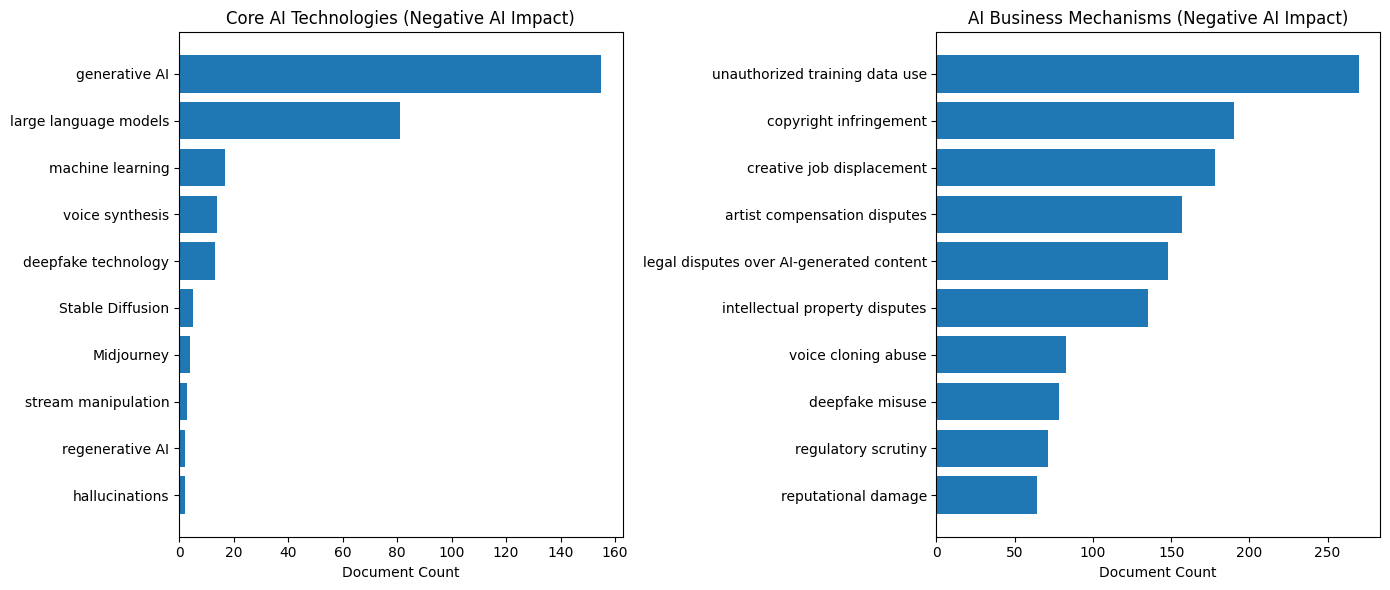

In [62]:
import matplotlib.pyplot as plt

tech_df = technology_top10_neg.sort_values("total_count")
mech_df = ai_mechanism_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

### Aggregated Sentiment Anaysis

In [75]:
df_ai_impact_pred = pd.read_parquet(f"{DATA_DIR}/Content_specific/content_ai_impact_classifier_predictions.parquet")

#### Topic Aggregation

In [64]:
Content_topics = pd.read_csv(f"{DATA_DIR}/Content_specific/Content_topics.csv")[['Topic','Representation','Representative_Docs']].copy()
Content_chunks_topics = pd.read_parquet(f"{DATA_DIR}/Content_specific/Content_chunks_topics.parquet")

In [79]:
manual_related_topics = [0,1,2,5,6,8,9,11,12,13,14,15,16,21,22]
Content_topics = Content_topics[Content_topics['Topic'].isin(manual_related_topics)]
Content_topics

,Topic,Representation,Representative_Docs,topic_summary
1,0,"['album', 'music industry', 'drake', 'tracks',...","['In June, the Recording Academy announced a s...",The Grammys' new rules require meaningful huma...
2,1,"['sag-aftra', 'performers', 'video game', 'gui...",['A representative for the studios did not imm...,SAG-AFTRA video game performers are striking o...
3,2,"['steam', 'gamer', 'npcs', 'valve', 'game deve...","['10. Added a ""Character Illustration Gallery""...",This topic is about video game updates and dev...
6,5,"['porn', 'sexual abuse', 'deepfakes', 'pornogr...",['Deepfake porn could be a growing problem ami...,This topic is about the creation and harm of n...
7,6,"['mckernan', 'painting', 'ortiz', 'paintings',...","[""Visual artists fight back against AI compani...",Artists suing AI companies for using their wor...
9,8,"['copyright office', 'fair use', 'diffusion', ...",['Generative AI – Copyright Overview Part 2 - ...,This topic is about copyright law's applicatio...
10,9,"['news corp', 'newsrooms', 'news organizations...","['AP, other news organizations develop standar...",News organizations establishing ethical guidel...
12,11,"['openai microsoft', 'microsoft openai', 'time...",['The New York Times sues ChatGPT creator Open...,The New York Times is suing OpenAI and Microso...
13,12,"['guild', 'authors guild', 'rasenberger', 'orl...",['Amazon to require some authors to disclose t...,Amazon now requires authors to disclose AI-gen...
14,13,"['seoul', 'telecom', 'k-pop', 'kakao', 'yoon',...","['Zuckerberg, South Korea\'s President Yoon ta...",This topic covers South Korean tech and cultur...


In [80]:
topic_summary_system_msg = """\
You are a topic interpretation system.

The user will provide:
- topic keywords
- representative documents

Your task:
Summarize what this topic is mainly about in one concise sentence (max 20 words).

Return plain text only.
"""
topic_summary_user_template = """\
Topic keywords:
{keywords}

Representative documents:
{docs}

What is this topic mainly about?
"""
def generate_text_plain(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0
    )
    return response.choices[0].message.content.strip()
summaries = []

for _, row in Content_topics.iterrows():
    
    keywords = row["Representation"]
    docs = row["Representative_Docs"]
    
    user_msg = topic_summary_user_template.format(
        keywords=str(keywords),
        docs=str(docs)[:4000]   # 防止太长
    )
    
    summary = generate_text_plain(
        client=client,
        system_msg=topic_summary_system_msg,
        user_msg=user_msg
    )
    
    summaries.append(summary)

Content_topics["topic_summary"] = summaries
show_full(Content_topics[["Topic", "Representation", "topic_summary"]])

C:\Users\ss363\AppData\Local\Temp\ipykernel_18400\296642504.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Content_topics["topic_summary"] = summaries


,Topic,Representation,topic_summary
1,0,"['album', 'music industry', 'drake', 'tracks', 'grammy', 'lyrics', 'suno', 'songwriters', 'recording academy', 'eligible']",The Grammys' new rules require meaningful human authorship for AI-influenced music to be eligible for awards.
2,1,"['sag-aftra', 'performers', 'video game', 'guild', 'wga', 'voice actors', 'filmmaking', 'filmmakers', 'film festival', 'crabtree-ireland']",SAG-AFTRA video game performers are striking over AI protections and fair compensation.
3,2,"['steam', 'gamer', 'npcs', 'valve', 'game development', 'nintendo', 'depot', 'xbox', 'gameplay', 'video games']",This topic is about video game updates and development tracked on the SteamDB platform.
6,5,"['porn', 'sexual abuse', 'deepfakes', 'pornography', 'child sexual', 'deepfake porn', 'stanford', 'nude', 'sexually', 'explicit images']",This topic is about the harmful use of AI to create nonconsensual deepfake pornography.
7,6,"['mckernan', 'painting', 'ortiz', 'paintings', 'auction', 'christie', 'digital art', 'karla', 'karla ortiz', 'exhibition']",Artists sue AI companies for using their work without consent to train image generators.
9,8,"['copyright office', 'fair use', 'diffusion', 'copyright protection', 'stable diffusion', 'authorship', 'outputs', 'copyright law', 'thaler', 'infringing']",This topic is about copyright law's application to AI-generated works and the requirement for human authorship.
10,9,"['news corp', 'newsrooms', 'news organizations', 'springer', 'axel springer', 'axel', 'organisations', 'news content', 'news organisations', 'news media']",News organizations establishing ethical guidelines for using artificial intelligence in journalism.
12,11,"['openai microsoft', 'microsoft openai', 'times sues', 'train chatbots', 'fair use', 'nyt', 'times said', 'billions dollars', 'sues openai', 'lawsuit openai']",The New York Times is suing OpenAI and Microsoft for using its articles to train AI chatbots without permission.
13,12,"['guild', 'authors guild', 'rasenberger', 'orlean', 'kindle', 'created humans', 'open letter', 'stacked', 'disclose', 'want sell']",Amazon now requires authors to disclose AI-generated content in books sold on its platform.
14,13,"['seoul', 'telecom', 'k-pop', 'kakao', 'yoon', 'south korean', 'herald', 'gil', 'yonhap', 'textbooks']","This topic covers South Korean tech, AI cooperation, and political engagements involving President Yoon and global leaders."


In [81]:
Content_topics_summary = Content_topics[["Topic", "Representation", "topic_summary"]].copy()

In [82]:
meta_topic_system_msg = """
You are a Media and Content Create Industry AI industry analyst.

The user will provide a list of lower-level topics extracted from Media and Content Create Industry AI news.

Each topic includes:
- Topic ID
- keyword representation
- short topic summary

Your task:
Group these topics into 3 to 5 higher-level Media and Content Create Industry AI themes.

Requirements:
- Create 3 to 5 meta-topics
- Assign every Topic ID to exactly one meta-topic
- Give each meta-topic:
  - meta_topic_label
  - meta_topic_summary
  - topic_ids (list of topic IDs)

Return JSON only.

Format:
{
  "meta_topics":[
    {
      "meta_topic_label":"...",
      "meta_topic_summary":"...",
      "topic_ids":[0,1,2]
    }
  ]
}
"""

topics_text = "\n\n".join(
    Content_topics_summary.apply(
        lambda r: f"""
Topic ID: {r['Topic']}
Keywords: {r['Representation']}
Summary: {r['topic_summary']}
""",
        axis=1
    )
)

user_msg = f"""
Group the following Media and Content Create Industry AI topics into 3–5 higher-level themes.

Topics:
{topics_text}

Return JSON only.
"""

meta_topic_schema = {
    "type": "object",
    "properties": {
        "meta_topics": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "meta_topic_label": {"type": "string"},
                    "meta_topic_summary": {"type": "string"},
                    "topic_ids": {
                        "type": "array",
                        "items": {"type": "integer"}
                    }
                },
                "required": ["meta_topic_label", "meta_topic_summary", "topic_ids"],
                "additionalProperties": False
            },
            "minItems": 3,
            "maxItems": 5
        }
    },
    "required": ["meta_topics"],
    "additionalProperties": False
}

In [84]:
import json

response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[
        {"role": "system", "content": meta_topic_system_msg},
        {"role": "user", "content": user_msg}
    ],
    temperature=0,
    response_format={"type": "json_object"}
)

meta_topics = json.loads(response.choices[0].message.content)

meta_topics

{'meta_topics': [{'meta_topic_label': 'Legal and Regulatory Challenges in AI Content Creation',
   'meta_topic_summary': 'This theme covers legal disputes, copyright issues, and regulatory frameworks surrounding AI-generated content, including lawsuits, fair use debates, and new rules from institutions like the Grammys and Copyright Office.',
   'topic_ids': [0, 6, 8, 11, 12, 14, 15]},
  {'meta_topic_label': 'Labor and Ethical Concerns in AI Media Production',
   'meta_topic_summary': 'This theme focuses on labor strikes, ethical guidelines, and harmful uses of AI in media, including performer protections, deepfake abuse, and newsroom ethics.',
   'topic_ids': [1, 5, 9, 13]},
  {'meta_topic_label': 'Creative Applications and Industry Integration of AI',
   'meta_topic_summary': 'This theme highlights practical uses of AI in creative industries, such as music production, video games, and entertainment, including collaborations and technological advancements.',
   'topic_ids': [2, 16, 21

In [85]:
rows = []

for m in meta_topics["meta_topics"]:
    for t in m["topic_ids"]:
        rows.append({
            "Topic": t,
            "meta_topic": m["meta_topic_label"],
            "meta_summary": m["meta_topic_summary"]
        })

df_meta = pd.DataFrame(rows)
Content_topics_5 = Content_topics_summary.merge(df_meta, on="Topic", how="left")
Content_topics_5

,Topic,Representation,topic_summary,meta_topic,meta_summary
0,0,"['album', 'music industry', 'drake', 'tracks',...",The Grammys' new rules require meaningful huma...,Legal and Regulatory Challenges in AI Content ...,"This theme covers legal disputes, copyright is..."
1,1,"['sag-aftra', 'performers', 'video game', 'gui...",SAG-AFTRA video game performers are striking o...,Labor and Ethical Concerns in AI Media Production,"This theme focuses on labor strikes, ethical g..."
2,2,"['steam', 'gamer', 'npcs', 'valve', 'game deve...",This topic is about video game updates and dev...,Creative Applications and Industry Integration...,This theme highlights practical uses of AI in ...
3,5,"['porn', 'sexual abuse', 'deepfakes', 'pornogr...",This topic is about the harmful use of AI to c...,Labor and Ethical Concerns in AI Media Production,"This theme focuses on labor strikes, ethical g..."
4,6,"['mckernan', 'painting', 'ortiz', 'paintings',...",Artists sue AI companies for using their work ...,Legal and Regulatory Challenges in AI Content ...,"This theme covers legal disputes, copyright is..."
5,8,"['copyright office', 'fair use', 'diffusion', ...",This topic is about copyright law's applicatio...,Legal and Regulatory Challenges in AI Content ...,"This theme covers legal disputes, copyright is..."
6,9,"['news corp', 'newsrooms', 'news organizations...",News organizations establishing ethical guidel...,Labor and Ethical Concerns in AI Media Production,"This theme focuses on labor strikes, ethical g..."
7,11,"['openai microsoft', 'microsoft openai', 'time...",The New York Times is suing OpenAI and Microso...,Legal and Regulatory Challenges in AI Content ...,"This theme covers legal disputes, copyright is..."
8,12,"['guild', 'authors guild', 'rasenberger', 'orl...",Amazon now requires authors to disclose AI-gen...,Legal and Regulatory Challenges in AI Content ...,"This theme covers legal disputes, copyright is..."
9,13,"['seoul', 'telecom', 'k-pop', 'kakao', 'yoon',...","This topic covers South Korean tech, AI cooper...",Labor and Ethical Concerns in AI Media Production,"This theme focuses on labor strikes, ethical g..."


In [86]:
df_ai_impact_pred["doc_id"] = df_ai_impact_pred["chunk_uid"].astype(str).str.split("_").str[0]
df_ai_impact_pred["doc_id"] = df_ai_impact_pred["doc_id"].astype(int)
df_ai_impact_pred['meta_topic'] = df_ai_impact_pred['topic'].map(Content_topics_5.set_index("Topic")["meta_topic"])

display(df_ai_impact_pred.head(2))

,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively,doc_id,meta_topic
0,14_0_0_0_0,https://www.musicradar.com/music-tech/artists-...,2025-11-27,"""Artists and songwriters will have full contro...",0,"""Artists and songwriters will have full contro...",negatively,0.683345,0.683345,0.080035,0.236619,14,Legal and Regulatory Challenges in AI Content ...
1,14_0_0_0_1,https://www.musicradar.com/music-tech/artists-...,2025-11-27,"""Artists and songwriters will have full contro...",0,Best picks for you\n\n“We’re seeing the future...,hard-to-say,0.506218,0.068543,0.506218,0.425239,14,Legal and Regulatory Challenges in AI Content ...


In [87]:
df_ai_impact_pred['topic'].value_counts()

topic
0     3736
1     2869
2     1816
5      825
6      813
8      571
9      560
11     478
12     459
13     427
14     401
15     380
16     379
21     221
22     221
Name: count, dtype: int64

In [91]:
# Group by meta_topic and pred_label, and count the nunique of doc_id in each group
aiimpact_topic_label_doc_counts = (
    df_ai_impact_pred
    .groupby(["meta_topic", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_counts")
    .reset_index()
    .pivot(index="meta_topic", columns="pred_label", values="doc_counts")
    .fillna(0)
    .reset_index()
)
display(aiimpact_topic_label_doc_counts)


# percentage calculation
aiimpact_topic_label_doc_prop = (
    aiimpact_topic_label_doc_counts
    .set_index("meta_topic")
    .pipe(lambda x: x.div(x.sum(axis=1), axis=0))
    .reset_index()
)

aiimpact_topic_label_doc_prop_pct = aiimpact_topic_label_doc_prop.copy()
cols = aiimpact_topic_label_doc_prop_pct.columns.drop("meta_topic")
aiimpact_topic_label_doc_prop_pct[cols] = (
    aiimpact_topic_label_doc_prop_pct[cols]
    .mul(100)
    .round(2)
    .astype(str)
    .add("%")
)
display(aiimpact_topic_label_doc_prop_pct)

# Topic-level impact polarity score
aiimpact_topic_label_doc_prop["impact_score"] = (
    aiimpact_topic_label_doc_prop["positively"]
    - aiimpact_topic_label_doc_prop["negatively"]
)

display(aiimpact_topic_label_doc_prop)

pred_label,meta_topic,hard-to-say,negatively,positively
0,Creative Applications and Industry Integration...,685,241,722
1,Labor and Ethical Concerns in AI Media Production,841,1425,552
2,Legal and Regulatory Challenges in AI Content ...,860,2256,1098


pred_label,meta_topic,hard-to-say,negatively,positively
0,Creative Applications and Industry Integration...,41.57%,14.62%,43.81%
1,Labor and Ethical Concerns in AI Media Production,29.84%,50.57%,19.59%
2,Legal and Regulatory Challenges in AI Content ...,20.41%,53.54%,26.06%


pred_label,meta_topic,hard-to-say,negatively,positively,impact_score
0,Creative Applications and Industry Integration...,0.415655,0.146238,0.438107,0.291869
1,Labor and Ethical Concerns in AI Media Production,0.298439,0.505678,0.195884,-0.309794
2,Legal and Regulatory Challenges in AI Content ...,0.204082,0.535358,0.260560,-0.274798


The correction assumes that the observed predicted label distribution is a noisy transformation of the true label distribution.

The confusion matrix describes how true labels are converted into predicted labels.

By inverting this transformation, we estimate the underlying true distribution of labels at the topic level.

In [90]:
labels = ["negatively", "hard-to-say", "positively"]

C = np.array([
    [0.89, 0.05, 0.05],
    [0.48, 0.52, 0.00],
    [0.05, 0.16, 0.79]
])

C_inv = np.linalg.inv(C.T)

def correct_distribution(row):
    pred_dist = row[labels].values.astype(float)
    corrected = C_inv @ pred_dist
    corrected = np.clip(corrected, 0, 1)
    corrected = corrected / corrected.sum()
    return corrected

corrected_values = np.vstack(aiimpact_topic_label_doc_prop.apply(correct_distribution, axis=1))

aiimpact_topic_label_doc_prop_corrected = aiimpact_topic_label_doc_prop.copy().drop(columns='impact_score')
aiimpact_topic_label_doc_prop_corrected[labels] = corrected_values

aiimpact_topic_label_doc_prop_corrected["impact_score_corrected"] = (
    aiimpact_topic_label_doc_prop_corrected["positively"]
    - aiimpact_topic_label_doc_prop_corrected["negatively"]
)
display(aiimpact_topic_label_doc_prop_corrected)

pred_label,meta_topic,hard-to-say,negatively,positively,impact_score_corrected
0,Creative Applications and Industry Integration...,0.531737,0.000000,0.468263,0.468263
1,Labor and Ethical Concerns in AI Media Production,0.473260,0.298413,0.228327,-0.070086
2,Legal and Regulatory Challenges in AI Content ...,0.255634,0.444117,0.300249,-0.143868


In [96]:
# Group by topic and pred_label, and count the nunique of doc_id in each group
aiimpact_topic_label_doc_counts = (
    df_ai_impact_pred
    .groupby(["topic", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_counts")
    .reset_index()
    .pivot(index="topic", columns="pred_label", values="doc_counts")
    .fillna(0)
    .reset_index()
)
display(aiimpact_topic_label_doc_counts)


# percentage calculation
aiimpact_topic_label_doc_prop = (
    aiimpact_topic_label_doc_counts
    .set_index("topic")
    .pipe(lambda x: x.div(x.sum(axis=1), axis=0))
    .reset_index()
)

aiimpact_topic_label_doc_prop_pct = aiimpact_topic_label_doc_prop.copy()
cols = aiimpact_topic_label_doc_prop_pct.columns.drop("topic")
aiimpact_topic_label_doc_prop_pct[cols] = (
    aiimpact_topic_label_doc_prop_pct[cols]
    .mul(100)
    .round(2)
    .astype(str)
    .add("%")
)

display(aiimpact_topic_label_doc_prop_pct)

# Topic-level impact polarity score
aiimpact_topic_label_doc_prop["impact_score"] = (
    aiimpact_topic_label_doc_prop["positively"]
    - aiimpact_topic_label_doc_prop["negatively"]
)
aiimpact_topic_label_doc_prop['topic_summary'] = aiimpact_topic_label_doc_prop['topic'].map(Content_topics.set_index("Topic")["topic_summary"])
show_full(aiimpact_topic_label_doc_prop)

pred_label,topic,hard-to-say,negatively,positively
0,0,523,940,888
1,1,466,883,332
2,2,521,163,429
3,5,33,393,9
4,6,130,204,141
5,8,86,231,19
6,9,113,138,148
7,11,17,270,5
8,12,79,192,25
9,13,232,16,65


pred_label,topic,hard-to-say,negatively,positively
0,0,22.25%,39.98%,37.77%
1,1,27.72%,52.53%,19.75%
2,2,46.81%,14.65%,38.54%
3,5,7.59%,90.34%,2.07%
4,6,27.37%,42.95%,29.68%
5,8,25.6%,68.75%,5.65%
6,9,28.32%,34.59%,37.09%
7,11,5.82%,92.47%,1.71%
8,12,26.69%,64.86%,8.45%
9,13,74.12%,5.11%,20.77%


pred_label,topic,hard-to-say,negatively,positively,impact_score,topic_summary
0,0,0.222459,0.399830,0.377712,-0.022118,The Grammys' new rules require meaningful human authorship for AI-influenced music to be eligible for awards.
1,1,0.277216,0.525283,0.197501,-0.327781,SAG-AFTRA video game performers are striking over AI protections and fair compensation.
2,2,0.468104,0.146451,0.385445,0.238994,This topic is about video game updates and development tracked on the SteamDB platform.
3,5,0.075862,0.903448,0.020690,-0.882759,This topic is about the harmful use of AI to create nonconsensual deepfake pornography.
4,6,0.273684,0.429474,0.296842,-0.132632,Artists sue AI companies for using their work without consent to train image generators.
5,8,0.255952,0.687500,0.056548,-0.630952,This topic is about copyright law's application to AI-generated works and the requirement for human authorship.
6,9,0.283208,0.345865,0.370927,0.025063,News organizations establishing ethical guidelines for using artificial intelligence in journalism.
7,11,0.058219,0.924658,0.017123,-0.907534,The New York Times is suing OpenAI and Microsoft for using its articles to train AI chatbots without permission.
8,12,0.266892,0.648649,0.084459,-0.564189,Amazon now requires authors to disclose AI-generated content in books sold on its platform.
9,13,0.741214,0.051118,0.207668,0.156550,"This topic covers South Korean tech, AI cooperation, and political engagements involving President Yoon and global leaders."


In [98]:
labels = ["negatively", "hard-to-say", "positively"]

C = np.array([
    [0.89, 0.05, 0.05],
    [0.48, 0.52, 0.00],
    [0.05, 0.16, 0.79]
])

C_inv = np.linalg.inv(C.T)

def correct_distribution(row):
    pred_dist = row[labels].values.astype(float)
    corrected = C_inv @ pred_dist
    corrected = np.clip(corrected, 0, 1)
    corrected = corrected / corrected.sum()
    return corrected

corrected_values = np.vstack(aiimpact_topic_label_doc_prop.apply(correct_distribution, axis=1))

aiimpact_topic_label_doc_prop_corrected = aiimpact_topic_label_doc_prop.copy().drop(columns='impact_score')
aiimpact_topic_label_doc_prop_corrected[labels] = corrected_values

aiimpact_topic_label_doc_prop_corrected["impact_score_corrected"] = (
    aiimpact_topic_label_doc_prop_corrected["positively"]
    - aiimpact_topic_label_doc_prop_corrected["negatively"]
)
show_full(aiimpact_topic_label_doc_prop_corrected)

pred_label,topic,hard-to-say,negatively,positively,topic_summary,impact_score_corrected
0,0,0.258202,0.282942,0.458855,The Grammys' new rules require meaningful human authorship for AI-influenced music to be eligible for awards.,0.175913
1,1,0.428199,0.344461,0.227339,SAG-AFTRA video game performers are striking over AI protections and fair compensation.,-0.117122
2,2,0.604105,0.000000,0.395895,This topic is about video game updates and development tracked on the SteamDB platform.,0.395895
3,5,0.059679,0.940321,0.000000,This topic is about the harmful use of AI to create nonconsensual deepfake pornography.,-0.940321
4,6,0.390456,0.250597,0.358947,Artists sue AI companies for using their work without consent to train image generators.,0.108350
5,8,0.426556,0.536184,0.037260,This topic is about copyright law's application to AI-generated works and the requirement for human authorship.,-0.498924
6,9,0.387811,0.153067,0.459122,News organizations establishing ethical guidelines for using artificial intelligence in journalism.,0.306054
7,11,0.025850,0.974150,0.000000,The New York Times is suing OpenAI and Microsoft for using its articles to train AI chatbots without permission.,-0.974150
8,12,0.440985,0.483203,0.075812,Amazon now requires authors to disclose AI-generated content in books sold on its platform.,-0.407392
9,13,0.764470,0.000000,0.235530,"This topic covers South Korean tech, AI cooperation, and political engagements involving President Yoon and global leaders.",0.235530


#### Time Aggregation

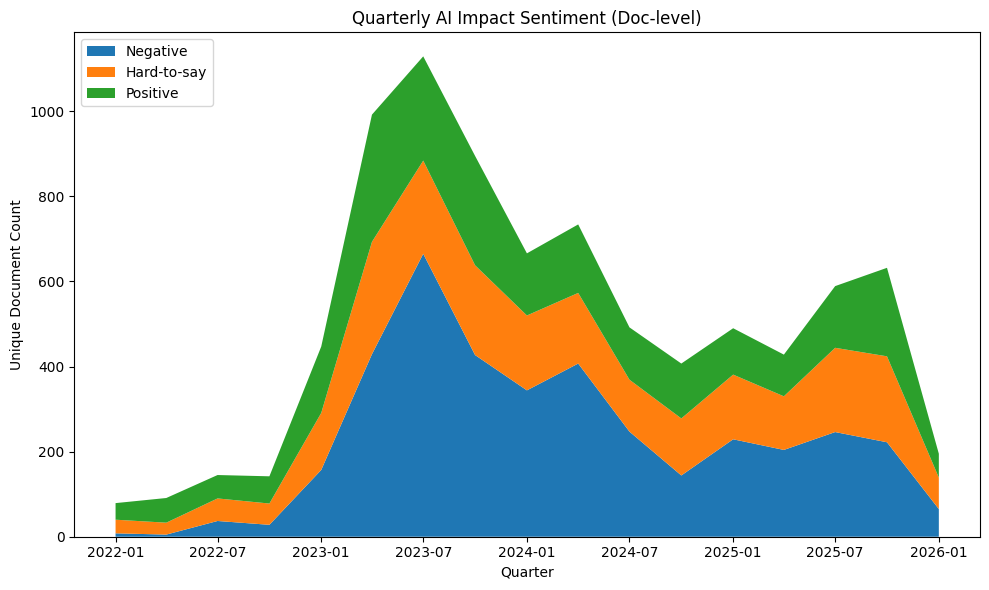

In [99]:
df_ai_impact_pred["date"] = pd.to_datetime(df_ai_impact_pred["date"])
df_ai_impact_pred["quarter"] = df_ai_impact_pred["date"].dt.to_period("Q")
quarter_sent_doc = (
    df_ai_impact_pred
    .groupby(["quarter", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_count")
    .reset_index()
)
quarter_sent_pivot = (
    quarter_sent_doc
    .pivot(index="quarter", columns="pred_label", values="doc_count")
    .fillna(0)
    .sort_index()
)

import matplotlib.pyplot as plt

quarter_sent_pivot.index = quarter_sent_pivot.index.to_timestamp()

plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_pivot.index,
    quarter_sent_pivot.get("negatively", 0),
    quarter_sent_pivot.get("hard-to-say", 0),
    quarter_sent_pivot.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level)")
plt.xlabel("Quarter")
plt.ylabel("Unique Document Count")
plt.tight_layout()
plt.show()

pred_label,hard-to-say,negatively,positively
quarter,,,
2022-01-01,0.405063,0.101266,0.493671
2022-04-01,0.307692,0.054945,0.637363
2022-07-01,0.365517,0.255172,0.379310
2022-10-01,0.352113,0.197183,0.450704
2023-01-01,0.299776,0.351230,0.348993
2023-04-01,0.266129,0.432460,0.301411
2023-07-01,0.193977,0.589017,0.217006
2023-10-01,0.235754,0.477095,0.287151
2024-01-01,0.264264,0.516517,0.219219


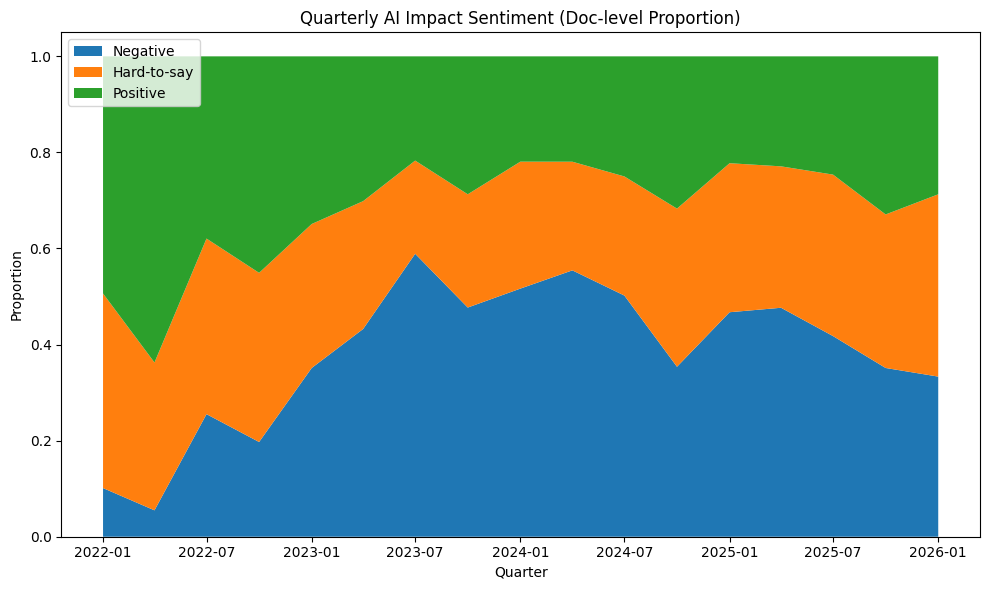

In [100]:
quarter_sent_prop = (
    quarter_sent_pivot
    .div(quarter_sent_pivot.sum(axis=1), axis=0)
)
display(quarter_sent_prop)

plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_prop.index,
    quarter_sent_prop.get("negatively", 0),
    quarter_sent_prop.get("hard-to-say", 0),
    quarter_sent_prop.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level Proportion)")
plt.xlabel("Quarter")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()